# Приоритизация обращений

Обучение модели на готовых табличных признаках из `train.csv` / `test.csv` и создание `submission.csv`. Также используем дополнительно `events.csv` для улучшения решения.

### Выполненные шаги

##### Шаг 0: Загрузка и запуск quickstart.ipynb
- Загружены библиотеки и данные
- Запущен baseline (Logistic Regression)
- Baseline AP = 0.48506

##### Шаг 1: Изучение данных (EDA)
- Размеры: train 13694 × 119, test 4306 × 118, events 254705 × 7
- Доля target = 20.75% (дисбаланс умеренный)
- 7 категориальных признаков: lead_source, call_center, region, car_segment, lead_channel, user_tenure_bucket, price_bucket
- 108 числовых признаков (агрегации за окна 1d, 3d, 7d, 14d, 30d, 90d)
- 5 типов событий: item_view, search, favorite, chat_open, call_click
- Пропуски: 97 из 119 колонок
- Распределение по датам: train 07.04–22.04 (16 дней), test 23.04–27.04 (5 дней) — тест позже train, используется временная валидация

##### Шаг 2: Флаги пропусков (is_missing)
- Добавлено 97 флагов пропусков для колонок с NaN
- Каждый флаг показывает, было ли пропущено значение в соответствующей колонке
- Итог: train (13694, 216), test (4306, 215)

##### Шаг 3: Построение признаков из events.csv
- Фильтрация событий ДО назначения (защита от читинга): 91.8% событий доступны
- Создано 8 новых признаков:
  - total_events — общее количество событий до назначения
  - unique_event_types — количество уникальных типов событий
  - event_span_days — разброс событий во времени
  - nw_item_view, nw_search, nw_favorite, nw_chat_open, nw_call_click — количество каждого типа событий
- Итог: train (13694, 224), test (4306, 223)

##### Шаг 4: Обучение LightGBM
- Модель: LightGBM с early stopping (50 раундов)
- Валидация: временная (80% дат — обучение, 20% — валидация)
- Категориальные признаки: преобразованы в тип category (LightGBM обрабатывает автоматически)
- Результат: AP = 0.55169 (улучшение на +13.7% относительно baseline)

##### Шаг 5: Оптимизация гиперпараметров
- Настройка гиперпараметров с помощью Optuna (15 trials)
- Лучшие параметры: num_leaves=29, learning_rate=0.0437, n_estimators=791 и далее
- Результат: AP = 0.56855 (улучшение на +1.93% относительно базового LightGBM, +17.2% относительно baseline)

##### Шаг 6: Анализ важности признаков
- Топ-3 важных признака: seller_page_views_30d, seller_page_views_14d, user_age_days
- Признаки из events попали в топ-30, подтверждая пользу feature engineering

### 1. Загрузка библиотек

In [19]:
# 1. Загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import lightgbm as lgb
from pathlib import Path
from datetime import datetime
from sklearn.metrics import average_precision_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import optuna

#import catboost (для обучения модели, показал худший результат по сравнению с lightGBM)
#import xgboost (для обучения модели, показал худший результат по сравнению с lightGBM)

warnings.filterwarnings('ignore')

### 2. Загрузка данных и анализ

Загружаем обучающую выборку, тестовую выборку и события: `train.csv`, `test.csv`, `events.csv`. Проводим анализ структуры данных, типов данных и пропусков, описательную статистику, распределение по датам (для понимания, что test идет после train).

In [20]:
# 2. Загрузка данных
ROOT = Path(".")
DATA_DIR = ROOT / "data"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
events = pd.read_csv(DATA_DIR / "events.csv")

# Константы
TARGET = "target"
RANDOM_STATE = 42

print("РАЗМЕРЫ ДАННЫХ")
print(f"train: {train.shape[0]} строк, {train.shape[1]} колонок")
print(f"test: {test.shape[0]} строк, {test.shape[1]} колонок")
print(f"events: {events.shape[0]} строк, {events.shape[1]} колонок")
print()


РАЗМЕРЫ ДАННЫХ
train: 13694 строк, 119 колонок
test: 4306 строк, 118 колонок
events: 254705 строк, 7 колонок



#### 2.1. Структура данных train.csv и events.csv

In [21]:
# Проверяем структуру данных train.csv
print("СТРУКТУРА train.csv")

all_cols = train.columns.tolist()
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_all = train.select_dtypes(include=['object']).columns.tolist()

display(train.head())

print(f"Всего колонок: {len(all_cols)}")
print(f"  Числовых: {len(numeric_cols)}")
print(f"  Категориальных: {len(cat_cols_all)}")
print()

print("ЦЕЛЕВАЯ ПЕРЕМЕННАЯ в train.csv")
print(f"Доля target=1: {train['target'].mean():.2%}")
print(f"Распределение:\n{train['target'].value_counts()}")
print()

СТРУКТУРА train.csv


,lead_id,user_id,assignment_ts,assignment_date,lead_source,call_center,region,car_segment,lead_channel,user_tenure_bucket,...,leadgen_prev_positive_14d,leadgen_prev_positive_30d,leadgen_prev_positive_90d,active_days_auto_1d,active_days_auto_3d,active_days_auto_7d,active_days_auto_14d,active_days_auto_30d,active_days_auto_90d,target
0,lead_f57db09ab39ae3e7,user_0000001,2026-04-22 11:56:00,2026-04-22,CRM,external,west,budget,retargeting,warm,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,9.0,26.0,0
1,lead_a6184b8a8165a27b,user_0000002,2026-04-07 14:49:00,2026-04-07,CRM,voxys,north,standard,partner,warm,...,0.0,NaN,1.0,0.0,0.0,0.0,NaN,4.0,5.0,0
2,lead_229c2a117dbac203,user_0000003,2026-04-12 17:01:00,2026-04-12,Perf,external,north,budget,retargeting,new,...,0.0,0.0,NaN,2.0,4.0,1.0,10.0,12.0,52.0,0
3,lead_16b19e58042ef905,user_0000005,2026-04-13 21:39:00,2026-04-13,Model,voxys,east,premium,partner,warm,...,0.0,1.0,0.0,0.0,1.0,0.0,3.0,2.0,NaN,1
4,lead_734c227324978a36,user_0000006,2026-04-12 18:01:00,2026-04-12,CRM,voxys,central,budget,retargeting,warm,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,9.0,0


Всего колонок: 119
  Числовых: 108
  Категориальных: 11

ЦЕЛЕВАЯ ПЕРЕМЕННАЯ в train.csv
Доля target=1: 20.75%
Распределение:
target
0    10853
1     2841
Name: count, dtype: int64



In [22]:
print("СТРУКТУРА events.csv")

display(events.head())

print("ТИПЫ СОБЫТИЙ В events.csv")
event_counts = events['event_type'].value_counts()
print(event_counts)
print(f"\nВсего типов: {len(event_counts)}")
print()

СТРУКТУРА events.csv


,lead_id,user_id,event_ts,event_type,item_price_log,src_slot,ctx_seq
0,lead_00025e9610a0d90d,user_0016636,2026-03-27 06:41:00,chat_open,13.303438,19.0,c02
1,lead_00025e9610a0d90d,user_0016636,2026-03-31 09:10:00,item_view,13.322707,6.0,c06
2,lead_00025e9610a0d90d,user_0016636,2026-04-02 22:04:00,item_view,13.395721,10.0,c06
3,lead_00025e9610a0d90d,user_0016636,2026-04-04 09:19:00,search,13.395955,10.0,c04
4,lead_00025e9610a0d90d,user_0016636,2026-04-07 12:36:00,item_view,13.472769,2.0,c02


ТИПЫ СОБЫТИЙ В events.csv
event_type
item_view     120905
search         61101
favorite       26333
chat_open      24797
call_click     21569
Name: count, dtype: int64

Всего типов: 5



#### 2.2. Распределение по времени

РАСПРЕДЕЛЕНИЕ ПО ДАТАМ
Train: 2026-04-07 00:00:00 - 2026-04-22 00:00:00 (16 дней)
Test:  2026-04-23 00:00:00 - 2026-04-27 00:00:00 (5 дней)

Топ-5 дней по количеству назначений (train):
assignment_date
2026-04-17    901
2026-04-15    899
2026-04-18    875
2026-04-07    873
2026-04-19    863
dtype: int64

Топ-5 дней по количеству назначений (test):
assignment_date
2026-04-23    915
2026-04-27    873
2026-04-24    862
2026-04-26    838
2026-04-25    818
dtype: int64

Сравнение дат (train vs test)
Train: 2026-04-07 00:00:00 - 2026-04-22 00:00:00
Test:  2026-04-23 00:00:00 - 2026-04-27 00:00:00
Test позже train. Используем временную валидацию



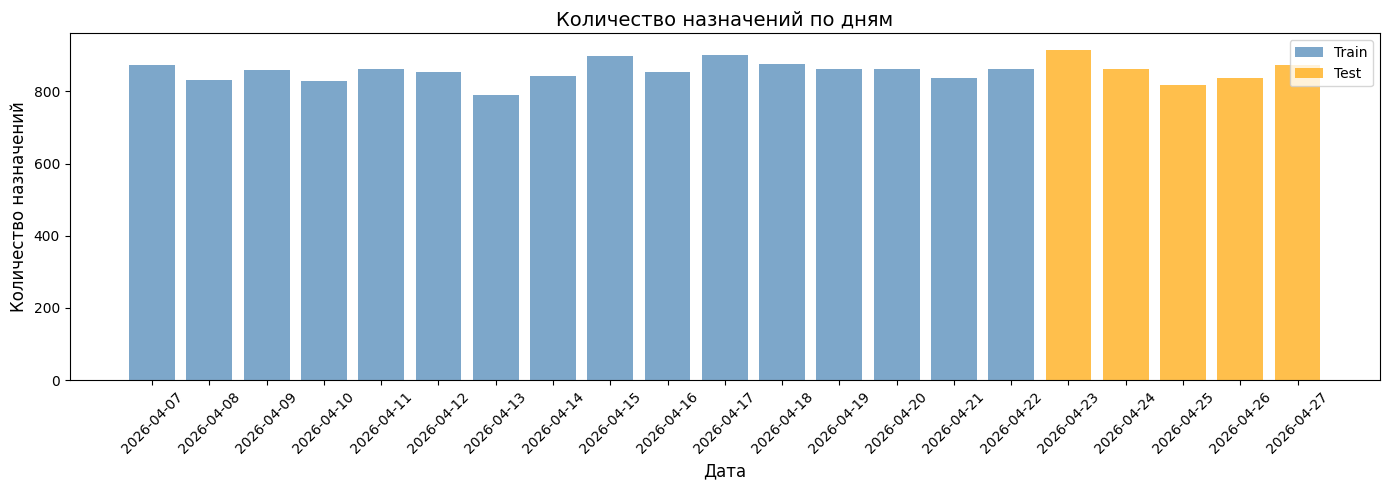

In [23]:
print("РАСПРЕДЕЛЕНИЕ ПО ДАТАМ")

# Конвертация дат
train['assignment_date'] = pd.to_datetime(train['assignment_date'])
test['assignment_date'] = pd.to_datetime(test['assignment_date'])

print(f"Train: {train['assignment_date'].min()} - {train['assignment_date'].max()} ({train['assignment_date'].nunique()} дней)")
print(f"Test:  {test['assignment_date'].min()} - {test['assignment_date'].max()} ({test['assignment_date'].nunique()} дней)")
print()

# Количество записей по дням (train)
daily_counts = train.groupby(train['assignment_date'].dt.date).size().sort_index()

print("Топ-5 дней по количеству назначений (train):")
print(daily_counts.sort_values(ascending=False).head(5))
print()

print("Топ-5 дней по количеству назначений (test):")
test_daily_counts = test.groupby(test['assignment_date'].dt.date).size().sort_index()
print(test_daily_counts.sort_values(ascending=False).head(5))
print()

# Проверка, что тест позже train
print("Сравнение дат (train vs test)")
print(f"Train: {train['assignment_date'].min()} - {train['assignment_date'].max()}")
print(f"Test:  {test['assignment_date'].min()} - {test['assignment_date'].max()}")

if test['assignment_date'].min() > train['assignment_date'].max():
    print("Test позже train. Используем временную валидацию")
else:
    print("Test пересекается с train по времени")
print()

# Визуализация (опционально)
plt.figure(figsize=(14, 5))
plt.bar(daily_counts.index.astype(str), daily_counts.values, color='steelblue', alpha=0.7, label='Train')
plt.bar(test_daily_counts.index.astype(str), test_daily_counts.values, color='orange', alpha=0.7, label='Test')
plt.title('Количество назначений по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество назначений', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### 2.3. Анализ пропусков

In [24]:
print("АНАЛИЗ ПРОПУСКОВ в train.csv")

missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Всего колонок с пропусками: {len(missing)} из {len(train.columns)}")
print()

if len(missing) > 0:
    print("Топ-10 колонок с пропусками:")
    for col in missing.head(10).index:
        cnt = missing[col]
        pct = cnt/len(train) * 100
        print(f"  {col:<35}:{cnt:>5} пропусков ({pct:>5.1f}%)")
else:
    print("Пропусков нет")
print()

АНАЛИЗ ПРОПУСКОВ в train.csv
Всего колонок с пропусками: 97 из 119

Топ-10 колонок с пропусками:
  seller_response_rate_30d           :  708 пропусков (  5.2%)
  leadgen_prev_positive_90d          :  452 пропусков (  3.3%)
  item_favorites_3d                  :  451 пропусков (  3.3%)
  query_refinements_30d              :  446 пропусков (  3.3%)
  detail_expands_3d                  :  445 пропусков (  3.2%)
  user_contacts_3d                   :  436 пропусков (  3.2%)
  leadgen_prev_assigned_7d           :  435 пропусков (  3.2%)
  call_clicks_14d                    :  434 пропусков (  3.2%)
  call_clicks_30d                    :  433 пропусков (  3.2%)
  user_contacts_14d                  :  433 пропусков (  3.2%)



#### 2.4. Описательная статистика для числовых и категориальных переменных

In [25]:
print("ЧИСЛОВЫЕ ПРИЗНАКИ в train.csv")

# Исключение target из числовых переменных
numeric_cols_no_target = [col for col in numeric_cols if col != TARGET]

desc = train[numeric_cols_no_target].describe().T
desc['missing'] = train[numeric_cols_no_target].isnull().sum()
desc['missing_pct'] = (desc['missing'] / len(train) * 100).round(1)

print("Топ-10 по среднему значению:")
print(desc.sort_values('mean', ascending=False).head(10)[['mean', 'std', 'min', 'max', 'missing_pct']])
print()

print("Топ-10 по пропускам:")
print(desc.sort_values('missing_pct', ascending=False).head(10)[['mean', 'std', 'min', 'max', 'missing_pct']])
print()

ЧИСЛОВЫЕ ПРИЗНАКИ в train.csv
Топ-10 по среднему значению:
                               mean         std   min     max  missing_pct
user_age_days            415.899664  420.696887   1.0  4088.0          0.0
item_views_90d            92.636869   52.931369  11.0   451.0          2.9
search_views_90d          56.158422   32.487257   5.0   279.0          3.0
photo_swipes_90d          46.844434   26.191584   3.0   223.0          3.0
item_views_30d            30.805566   18.101935   0.0   159.0          2.9
search_views_30d          18.675333   11.285385   0.0    99.0          3.1
similar_item_clicks_90d   18.423641   10.911632   0.0    94.0          2.9
seller_inventory_count    17.466409   17.781823   1.0   184.0          0.0
photo_swipes_30d          15.481554    9.485460   0.0    87.0          3.0
assignment_hour           14.477654    2.800490   9.0    21.0          0.0

Топ-10 по пропускам:
                               mean       std       min        max  \
seller_response_rate_30d

In [26]:
print("КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ в train.csv")

# Колонки, которые не используем как признаки модели
ID_COLUMNS = {"lead_id", "user_id"}
TIME_COLUMNS = {"assignment_ts", "assignment_date"}
NON_FEATURE_COLUMNS = ID_COLUMNS | TIME_COLUMNS | {TARGET, "split"}

ignore_cols = list(ID_COLUMNS | TIME_COLUMNS)
cat_cols_ignore = [col for col in cat_cols_all if col in ignore_cols]

# Категориальные колонки, которые используем как признаки
cat_cols_features = [col for col in cat_cols_all if col not in ignore_cols]
print(f"Не используем как признаки: {cat_cols_ignore}")
print()
print("Используем как признаки:")
for col in cat_cols_features:
    freq = train[col].value_counts().head(3)
    freq_dict = {k: int(v) for k, v in freq.items()}
    print(f"  * {col}: {train[col].nunique()} уникальных значений \n{freq_dict}")
print()

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ в train.csv
Не используем как признаки: ['lead_id', 'user_id', 'assignment_ts', 'assignment_date']

Используем как признаки:
  * lead_source: 3 уникальных значений 
{'Model': 5688, 'CRM': 4839, 'Perf': 3167}
  * call_center: 2 уникальных значений 
{'external': 7882, 'voxys': 5812}
  * region: 5 уникальных значений 
{'east': 2796, 'west': 2770, 'central': 2725}
  * car_segment: 4 уникальных значений 
{'standard': 5780, 'budget': 4713, 'premium': 1909}
  * lead_channel: 4 уникальных значений 
{'web': 3518, 'app': 3408, 'retargeting': 3385}
  * user_tenure_bucket: 3 уникальных значений 
{'warm': 6175, 'new': 4121, 'loyal': 3398}
  * price_bucket: 3 уникальных значений 
{'mid': 7076, 'low': 4170, 'high': 2448}



In [27]:
# ============================================
# 2.5. ФЛАГИ ПРОПУСКОВ (is_missing)
# ============================================

print("=" * 70)
print("ДОБАВЛЕНИЕ ФЛАГОВ ПРОПУСКОВ")
print("=" * 70)

# 1. Находим колонки с пропусками в исходных данных
cols_with_missing = train.columns[
    train.isnull().any()
].tolist()

# Исключаем ID, время и target
ID_COLUMNS = {"lead_id", "user_id"}
TIME_COLUMNS = {"assignment_ts", "assignment_date"}
cols_with_missing = [
    col for col in cols_with_missing
    if col not in ID_COLUMNS | TIME_COLUMNS | {TARGET}
]

print(f"Колонок с пропусками: {len(cols_with_missing)}")
print(f"Примеры: {cols_with_missing[:5]}...")
print()

# 2. Добавляем флаги в train и test
for col in cols_with_missing:
    train[f'{col}_is_missing'] = train[col].isnull().astype(int)
    test[f'{col}_is_missing'] = test[col].isnull().astype(int)

print(f"✅ Добавлено {len(cols_with_missing)} флагов пропусков")
print(f"Теперь train: {train.shape[1]} колонок")
print(f"Теперь test:  {test.shape[1]} колонок")

ДОБАВЛЕНИЕ ФЛАГОВ ПРОПУСКОВ
Колонок с пропусками: 97
Примеры: ['seller_response_rate_30d', 'item_views_1d', 'item_views_3d', 'item_views_7d', 'item_views_14d']...

✅ Добавлено 97 флагов пропусков
Теперь train: 216 колонок
Теперь test:  215 колонок


### 3. Построение признаков из events.csv

In [28]:
print("ПОСТРОЕНИЕ НОВЫХ ПРИЗНАКОВ ИЗ EVENTS.CSV")

# 1. Конвертация времени
events['event_ts'] = pd.to_datetime(events['event_ts'])
train['assignment_ts'] = pd.to_datetime(train['assignment_ts'])
test['assignment_ts'] = pd.to_datetime(test['assignment_ts'])

# 2. Фильтрование событий до назначения (защита от data leakage)
events_train = events.merge(
    train[['lead_id', 'assignment_ts']],
    on='lead_id',
    how='inner'
)

events_before = events_train[events_train['event_ts'] < events_train['assignment_ts']]

print(f"Событий до назначения: {len(events_before)} из {len(events_train)}")
print(f"Это {len(events_before)/len(events_train)*100:.1f}% от всех событий")
print()

# 3. Агрегация событий по каждому обращению

# 3.1. Общее количество событий
event_features = events_before.groupby('lead_id').agg(
    total_events=('event_ts', 'count')
).reset_index()

# 3.2. Количество уникальных типов событий
event_types_count = events_before.groupby('lead_id')['event_type'].nunique().reset_index()
event_types_count.columns = ['lead_id', 'unique_event_types']
event_features = event_features.merge(event_types_count, on='lead_id', how='left')

# 3.3. Разброс событий во времени (Сколько дней прошло между первым и последним событием)
def days_between(x):
    return (x.max() - x.min()).days if len(x) > 1 else 0

event_days = events_before.groupby('lead_id')['event_ts'].agg(days_between).reset_index()
event_days.columns = ['lead_id', 'event_span_days']
event_features = event_features.merge(event_days, on='lead_id', how='left')

# 3.4. Количество событий каждого типа (также добавление префикса 'nw_' к новым признакам для понимания)
event_pivot = pd.crosstab(
    events_before['lead_id'],
    events_before['event_type']
).reset_index().rename_axis(None, axis=1)

event_pivot.columns = ['lead_id'] + [f'nw_{col}' for col in event_pivot.columns if col != 'lead_id']

# Объединение всех признаков
event_features = event_features.merge(event_pivot, on='lead_id', how='left').fillna(0)

print("СПИСОК НОВЫХ ПРИЗНАКОВ ИЗ EVENTS:")

# Все колонки в event_features (кроме lead_id)
new_feature_cols = [col for col in event_features.columns if col != 'lead_id']

for i, col in enumerate(new_feature_cols, 1):
    sample_val = event_features[col].iloc[0]
    print(f"  {i:2d}. {col:<25} | пример: {sample_val}") # Это пример значения признака

print()
print(f"Итого: {len(new_feature_cols)} новых признаков")
print()

# 4. Присоединение к train и test
train_with_events = train.merge(event_features, on='lead_id', how='left').fillna(0)
test_with_events = test.merge(event_features, on='lead_id', how='left').fillna(0)

print(f"train с новыми признаками: {train_with_events.shape}")
print(f"test с новыми признаками:  {test_with_events.shape}")
print()

# Проверка: все ли lead_id из train есть в event_features
missing_in_train = set(train['lead_id']) - set(event_features['lead_id'])
if missing_in_train:
    print(f" !{len(missing_in_train)} обращений без событий!")
else:
    print("Все обращения имеют события")
print()

print("\nСТАТИСТИКА НОВЫХ ПРИЗНАКОВ:")
print(event_features[new_feature_cols].describe().round(2))

ПОСТРОЕНИЕ НОВЫХ ПРИЗНАКОВ ИЗ EVENTS.CSV
Событий до назначения: 181297 из 197421
Это 91.8% от всех событий

СПИСОК НОВЫХ ПРИЗНАКОВ ИЗ EVENTS:
   1. total_events              | пример: 10
   2. unique_event_types        | пример: 4
   3. event_span_days           | пример: 22
   4. nw_call_click             | пример: 1
   5. nw_chat_open              | пример: 1
   6. nw_favorite               | пример: 0
   7. nw_item_view              | пример: 6
   8. nw_search                 | пример: 2

Итого: 8 новых признаков

train с новыми признаками: (13694, 224)
test с новыми признаками:  (4306, 223)

 !20 обращений без событий!


СТАТИСТИКА НОВЫХ ПРИЗНАКОВ:
       total_events  unique_event_types  event_span_days  nw_call_click  \
count      13674.00            13674.00         13674.00       13674.00   
mean          13.26                3.91            24.50           1.07   
std            6.29                0.97             4.73           1.11   
min            1.00                1.00

### 4. Валидация и обучение модели

#### 4.1. Определение признаков для обучения модели

In [29]:
# Список признаков (все колонки, кроме ID, time и target)
feature_columns = [
    col for col in train_with_events.columns
    if col not in NON_FEATURE_COLUMNS
    and col in test_with_events.columns
]

print("СПИСОК ВСЕХ ПРИЗНАКОВ")

print(f"Всего признаков: {len(feature_columns)}")
print()
# Выводим все признаки (было 127 после добавления признаков из events, убираем 4 категориальных признака (ID, Time) и таргет= 122 признака)

СПИСОК ВСЕХ ПРИЗНАКОВ
Всего признаков: 219



#### 4.2. Валидация

Так как тестовая выборка находится позже train по времени, валидиция на последних датах train.

In [30]:
print("ВАЛИДАЦИЯ")
"""Делит train по времени: ранние даты в обучение, поздние даты в валидацию."""
# Берем все уникальные даты
dates = pd.to_datetime(train_with_events['assignment_date']).dt.date
unique_dates = sorted(dates.unique())

# Отрезаем 20% последних дат для валидации
cutoff_idx = int(len(unique_dates) * 0.8)
cutoff_date = unique_dates[cutoff_idx]

# Делим
train_part = train_with_events[dates < cutoff_date].copy()
valid_part = train_with_events[dates >= cutoff_date].copy()

print(f"train_part: {train_part.shape[0]} строк (даты до {cutoff_date})")
print(f"valid_part: {valid_part.shape[0]} строк (даты с {cutoff_date})")

ВАЛИДАЦИЯ
train_part: 10272 строк (даты до 2026-04-19)
valid_part: 3422 строк (даты с 2026-04-19)


In [31]:
print("ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

# Находим категориальные признаки с типом object для дальнейшего обучения модели
cat_columns = train_part.select_dtypes(include=['object']).columns.tolist()
print(f"Найдено категориальных признаков: {len(cat_columns)}")
print(f"{cat_columns}")

# Преобразуем в тип 'category' во всех выборках
for col in cat_columns:
    train_part[col] = train_part[col].astype('category')
    valid_part[col] = valid_part[col].astype('category')
    test_with_events[col] = test_with_events[col].astype('category')
    train_with_events[col] = train_with_events[col].astype('category')

# Проверяем
cat_columns_checked = train_part.select_dtypes(include=['category']).columns.tolist()
print(f"Преобразовано в 'category': {len(cat_columns_checked)} колонок")

ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
Найдено категориальных признаков: 9
['lead_id', 'user_id', 'lead_source', 'call_center', 'region', 'car_segment', 'lead_channel', 'user_tenure_bucket', 'price_bucket']
Преобразовано в 'category': 9 колонок


#### 4.3. Обучение модели

Используем **LightGBM** с early stopping:

Сначала обучаем модель без Optuna, далее уже с помощью.

- Категориальные признаки: преобразованы в тип `category`; LightGBM обрабатывает их автоматически через `categorical_feature='auto'`
- Дисбаланс классов: модель оптимизирует ROC-AUC (`metric='auc'`), которая устойчива к дисбалансу
- Валидация: early stopping (50 раундов без улучшения AUC на валидации)
- Финальная метрика: **Average Precision (AP)** — соответствует условиям задачи
- Гиперпараметры: настраиваются с помощью Optuna

In [32]:
print("ОБУЧЕНИЕ LIGHTGBM (baseline)")

params_base = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': -1,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
}

model_base = lgb.LGBMClassifier(**params_base)
model_base.fit(
    train_part[feature_columns],
    train_part[TARGET],
    eval_set=[(valid_part[feature_columns], valid_part[TARGET])],
    eval_metric='auc',
    categorical_feature='auto',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

valid_scores_base = model_base.predict_proba(valid_part[feature_columns])[:, 1]
valid_ap_base = average_precision_score(valid_part[TARGET], valid_scores_base)

print(f"LightGBM (baseline) AP: {valid_ap_base:.5f}")
print(f"Улучшение от baseline: {((valid_ap_base - 0.48506) / 0.48506 * 100):.1f}%")
print()

ОБУЧЕНИЕ LIGHTGBM (baseline)
LightGBM (baseline) AP: 0.55169
Улучшение от baseline: 13.7%



In [33]:
print("НАСТРОЙКА ГИПЕРПАРАМЕТРОВ (Optuna)")

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'verbose': -1,
        'random_state': 42,
        'n_jobs': -1,
    }
    
    model = lgb.LGBMClassifier(**params)
    model.fit(
        train_part[feature_columns],
        train_part[TARGET],
        eval_set=[(valid_part[feature_columns], valid_part[TARGET])],
        eval_metric='auc',
        categorical_feature='auto',
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    
    scores = model.predict_proba(valid_part[feature_columns])[:, 1]
    ap = average_precision_score(valid_part[TARGET], scores)
    return ap

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=15, show_progress_bar=True)

print()
print(f"Лучший AP на валидации (Optuna): {study.best_value:.5f}")
print()

[I 2026-07-17 15:23:49,389] A new study created in memory with name: no-name-e7d8aa52-7b38-4b78-b121-2e020e4dd2de


НАСТРОЙКА ГИПЕРПАРАМЕТРОВ (Optuna)


Best trial: 0. Best value: 0.54236:   7%|▋         | 1/15 [00:01<00:18,  1.29s/it]

[I 2026-07-17 15:23:50,683] Trial 0 finished with value: 0.5423603837781279 and parameters: {'num_leaves': 44, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'n_estimators': 719, 'min_child_samples': 12, 'feature_fraction': 0.5701975341512912, 'bagging_fraction': 0.5261376254756898, 'bagging_freq': 9, 'reg_alpha': 0.002570603566117596, 'reg_lambda': 0.02358594058414266}. Best is trial 0 with value: 0.5423603837781279.


Best trial: 0. Best value: 0.54236:  13%|█▎        | 2/15 [00:01<00:09,  1.32it/s]

...

[I 2026-07-17 15:24:08,834] Trial 12 finished with value: 0.5361237287468975 and parameters: {'num_leaves': 74, 'max_depth': 3, 'learning_rate': 0.017359188951304567, 'n_estimators': 682, 'min_child_samples': 42, 'feature_fraction': 0.7490105013664863, 'bagging_fraction': 0.7165798218347101, 'bagging_freq': 4, 'reg_alpha': 1.5662989174678808e-06, 'reg_lambda': 1.1896890571855779e-08}. Best is trial 3 with value: 0.5613108383301748.


Best trial: 13. Best value: 0.568551:  93%|█████████▎| 14/15 [00:20<00:01,  1.37s/it]

[I 2026-07-17 15:24:10,324] Trial 13 finished with value: 0.5685507698548535 and parameters: {'num_leaves': 29, 'max_depth': 10, 'learning_rate': 0.04366549802221141, 'n_estimators': 791, 'min_child_samples': 42, 'feature_fraction': 0.6395167521975207, 'bagging_fraction': 0.7215373529612784, 'bagging_freq': 1, 'reg_alpha': 0.021208363647767944, 'reg_lambda': 1.1301475789216591e-05}. Best is trial 13 with value: 0.5685507698548535.


Best trial: 13. Best value: 0.568551: 100%|██████████| 15/15 [00:22<00:00,  1.49s/it]

[I 2026-07-17 15:24:11,734] Trial 14 finished with value: 0.5513818349813375 and parameters: {'num_leaves': 47, 'max_depth': 8, 'learning_rate': 0.04256748656624004, 'n_estimators': 807, 'min_child_samples': 45, 'feature_fraction': 0.5204026962842976, 'bagging_fraction': 0.6708476068082256, 'bagging_freq': 1, 'reg_alpha': 0.07859492060092772, 'reg_lambda': 4.638704084075335e-05}. Best is trial 13 with value: 0.5685507698548535.

Лучший AP на валидации (Optuna): 0.56855



In [34]:
print("ОБУЧЕНИЕ LIGHTGBM (ОПТИМИЗИРОВАННЫЙ)")

best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
})

model_opt = lgb.LGBMClassifier(**best_params)
model_opt.fit(
    train_part[feature_columns],
    train_part[TARGET],
    eval_set=[(valid_part[feature_columns], valid_part[TARGET])],
    eval_metric='auc',
    categorical_feature='auto',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

valid_scores_opt = model_opt.predict_proba(valid_part[feature_columns])[:, 1]
valid_ap_opt = average_precision_score(valid_part[TARGET], valid_scores_opt)

print("ИТОГОВОЕ СРАВНЕНИЕ")
print(f"Baseline Logistic Regression:  0.48506")
print(f"LightGBM (baseline):              {valid_ap_base:.5f}")
print(f"LightGBM (оптимизированный):     {valid_ap_opt:.5f}")
print(f"Улучшение от оптимизации:        {((valid_ap_opt - valid_ap_base) / valid_ap_base * 100):.2f}%")
print(f"Общее улучшение от baseline Logistic Regression:     {((valid_ap_opt - 0.48506) / 0.48506 * 100):.1f}%")

ОБУЧЕНИЕ LIGHTGBM (ОПТИМИЗИРОВАННЫЙ)
ИТОГОВОЕ СРАВНЕНИЕ
Baseline Logistic Regression:  0.48506
LightGBM (baseline):              0.55169
LightGBM (оптимизированный):     0.56855
Улучшение от оптимизации:        3.06%
Общее улучшение от baseline Logistic Regression:     17.2%


#### 4.4. Анализ важности признаков

АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
ТОП-20 ВАЖНЫХ ПРИЗНАКОВ:
                 feature  importance
   seller_page_views_30d         438
   seller_page_views_14d         360
           user_age_days         274
    seller_page_views_7d         254
        search_views_90d         240
          mileage_km_log         235
        photo_swipes_90d         217
           car_age_years         204
          item_views_90d         201
seller_response_rate_30d         189
          item_price_log         184
      detail_expands_90d         173
          item_views_14d         148
        photo_swipes_30d         146
  seller_inventory_count         142
   query_refinements_90d         137
         search_views_7d         133
            total_events         132
 similar_item_clicks_90d         131
       user_contacts_30d         131

ПРИЗНАКИ ИЗ EVENTS В ТОП-30:
           feature  importance
      total_events         132
   event_span_days         126
         nw_search         114
       nw_favorite

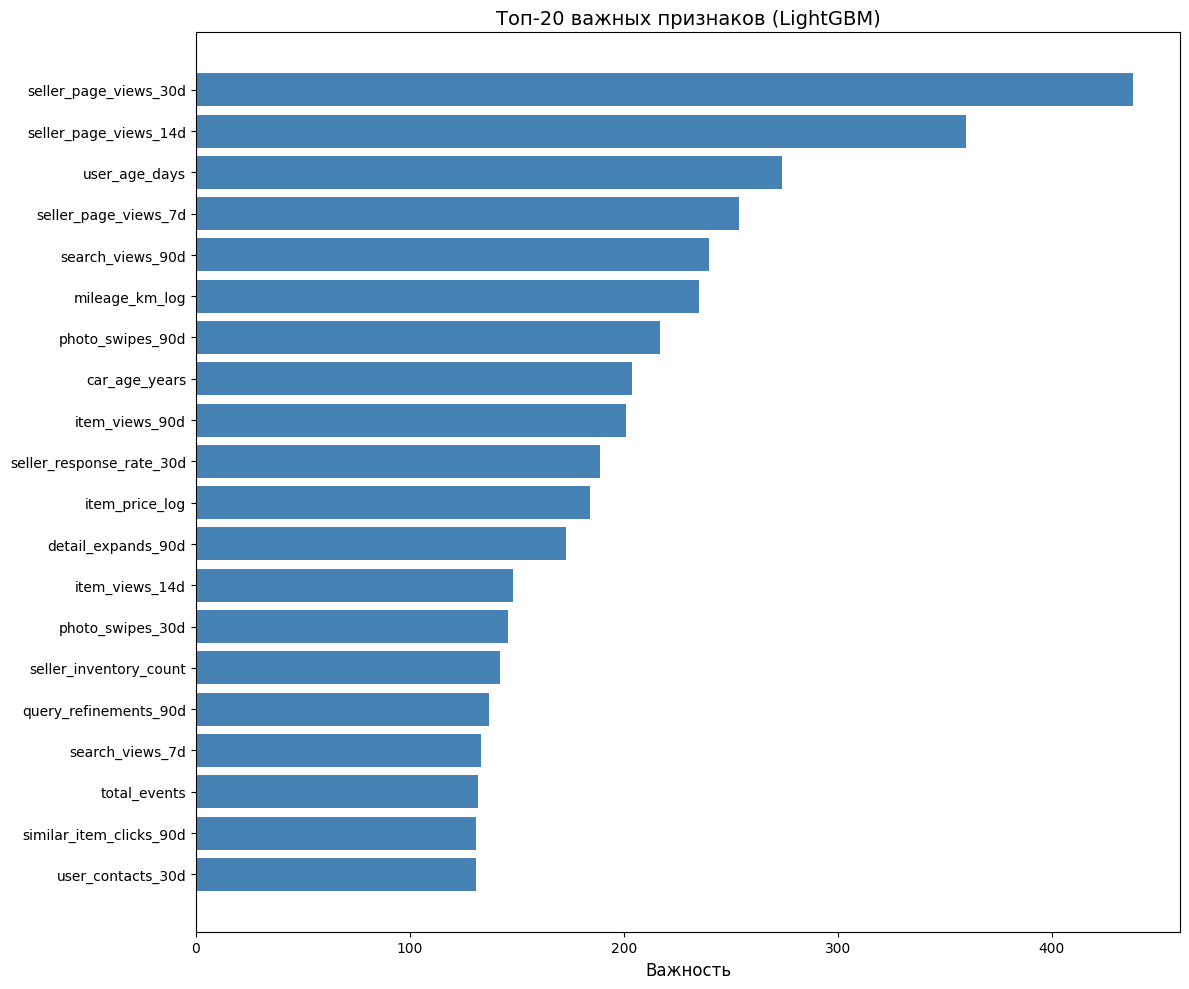

In [35]:
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model_opt.feature_importances_
}).sort_values('importance', ascending=False)

print("ТОП-20 ВАЖНЫХ ПРИЗНАКОВ:")
print(importance.head(20).to_string(index=False))
print()

# Проверка, что точно попали признаки из events в топ-30
print("ПРИЗНАКИ ИЗ EVENTS В ТОП-30:")
events_features = [col for col in feature_columns if col.startswith('nw_') or col in ['total_events', 'unique_event_types', 'event_span_days']]
events_importance = importance[importance['feature'].isin(events_features)]
print(events_importance.to_string(index=False))
print()

# Визуализация
plt.figure(figsize=(12, 10))
plt.barh(importance['feature'][:20], importance['importance'][:20], color='steelblue')
plt.title('Топ-20 важных признаков (LightGBM)', fontsize=14)
plt.xlabel('Важность', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### 5. Формирование submission 

In [36]:
print("ФИНАЛЬНЫЙ SUBMISSION")

# Обучение на всех данных train (с лучшими параметрами после OPtuna)
model_final = lgb.LGBMClassifier(**best_params)
model_final.fit(
    train_with_events[feature_columns],
    train_with_events[TARGET],
    categorical_feature='auto'
)

# Предсказания на test выборке (на всей выборке)
test_scores = model_final.predict_proba(test_with_events[feature_columns])[:, 1]

# Создание submission
submission = pd.DataFrame({
    "lead_id": test_with_events["lead_id"].astype(str),
    "score": test_scores
})

submission.to_csv("submission_final.csv", index=False)

print(f"submission_final.csv сохранён! ({len(submission)} строк)")
print("\nПервые 5 строк:")
print(submission.head())

# Проверка формата для отправки
assert list(submission.columns) == ["lead_id", "score"]
assert len(submission) == len(test_with_events)
assert submission["lead_id"].is_unique
assert submission["score"].between(0, 1).all()

print("\nФайл готов к отправке.")

ФИНАЛЬНЫЙ SUBMISSION
submission_final.csv сохранён! (4306 строк)

Первые 5 строк:
                 lead_id     score
0  lead_97e409eb8f8c8246  0.556446
1  lead_55310edb4489f9e9  0.102137
2  lead_e7f653a2c6a7eee8  0.812291
3  lead_22f8e1cfc487ac20  0.028979
4  lead_48b638b839abfac3  0.061444

Файл готов к отправке.
